In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
from sklearn.model_selection import train_test_split

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
from sklearn.metrics import mean_absolute_error, r2_score

In [7]:
# Creating Student Exam Score Dataset

import pandas as pd

data = {
    "Hours_Studied": [1, 2, 3, 4, 5, 6, 7, 8, 2, 9,
                      3, 5, 6, 4, 7, 8, 1, 9, 5, 6],
    
    "Attendance": [55, 60, 65, 70, 75, 80, 85, 90, 58, 95,
                   68, 74, 78, 72, 88, 92, 50, 96, 76, 82],
    
    "Previous_Score": [45, 50, 55, 60, 65, 70, 75, 80, 48, 85,
                       58, 66, 72, 63, 77, 83, 42, 88, 69, 74],
    
    "Final_Score": [48, 54, 59, 65, 70, 76, 82, 87, 52, 92,
                    62, 71, 78, 68, 84, 89, 46, 94, 73, 79]
}

df = pd.DataFrame(data)



In [8]:
df

,Hours_Studied,Attendance,Previous_Score,Final_Score
0,1,55,45,48
1,2,60,50,54
2,3,65,55,59
3,4,70,60,65
4,5,75,65,70
5,6,80,70,76
6,7,85,75,82
7,8,90,80,87
8,2,58,48,52
9,9,95,85,92


In [9]:
print(df.head())
print(df.tail())
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

   Hours_Studied  Attendance  Previous_Score  Final_Score
0              1          55              45           48
1              2          60              50           54
2              3          65              55           59
3              4          70              60           65
4              5          75              65           70
    Hours_Studied  Attendance  Previous_Score  Final_Score
15              8          92              83           89
16              1          50              42           46
17              9          96              88           94
18              5          76              69           73
19              6          82              74           79
(20, 4)
Hours_Studied     int64
Attendance        int64
Previous_Score    int64
Final_Score       int64
dtype: object
Hours_Studied     0
Attendance        0
Previous_Score    0
Final_Score       0
dtype: int64


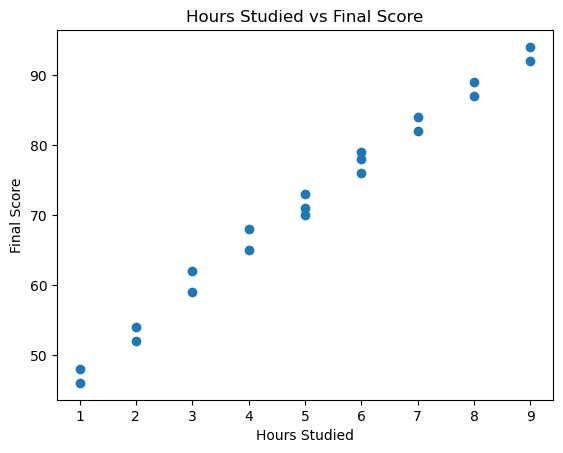

In [10]:
#Scatter_plot
plt.scatter(df["Hours_Studied"], df["Final_Score"])
plt.title("Hours Studied vs Final Score")
plt.xlabel("Hours Studied")
plt.ylabel("Final Score")
plt.show()

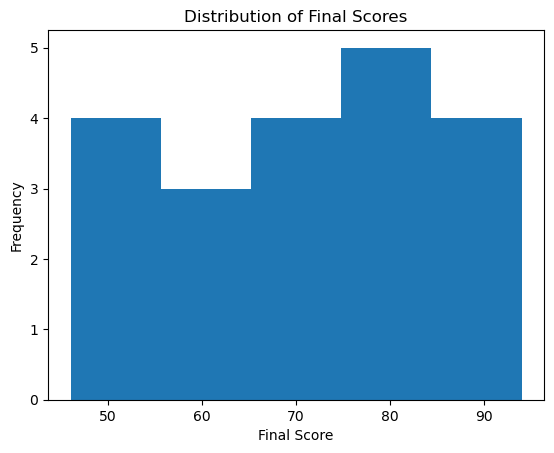

In [11]:
#Histogram
plt.hist(df["Final_Score"], bins=5)
plt.title("Distribution of Final Scores")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.show()

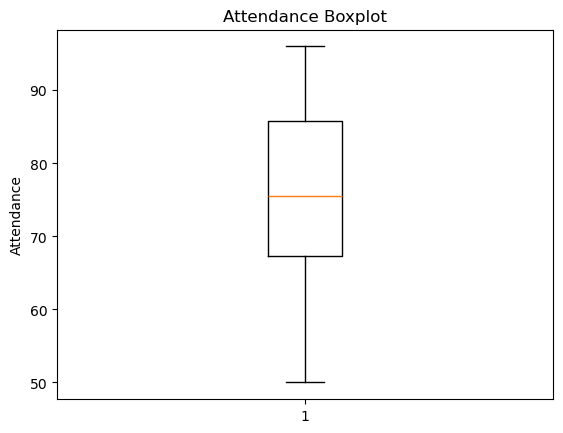

In [12]:
#Boxplot
plt.boxplot(df["Attendance"])
plt.title("Attendance Boxplot")
plt.ylabel("Attendance")
plt.show()

In [13]:
X = df[["Hours_Studied", "Attendance", "Previous_Score"]]
y = df["Final_Score"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
y_pred = model.predict(X_test)

In [17]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 0.4897346917958103
R2 Score: 0.9991905447512771


The Mean Absolute Error shows the average difference between predicted and actual scores.
The R2 score indicates how well the model explains the variation in final scores.
Since the R2 value is close to 1, the model performs well.
Study hours and previous performance significantly impact final exam score.

In [18]:
# Removing Attendance feature

X2 = df[["Hours_Studied", "Previous_Score"]]
y2 = df["Final_Score"]

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

print("MAE (Without Attendance):", mean_absolute_error(y_test2, y_pred2))
print("R2 (Without Attendance):", r2_score(y_test2, y_pred2))

MAE (Without Attendance): 0.5092710997442467
R2 (Without Attendance): 0.9991081451717119


After removing the Attendance feature, the MAE slightly increased and R² slightly decreased.
This indicates that Attendance contributes to predicting final exam scores.
However, the impact is small because the dataset has a strong linear relationship between features.
Therefore, Attendance is useful but not the most dominant feature.

In [19]:
# Adding new feature: Study Efficiency
df["Study_Efficiency"] = df["Hours_Studied"] * df["Attendance"] / 100

In [20]:
X3 = df[["Hours_Studied", "Attendance", "Previous_Score", "Study_Efficiency"]]
y3 = df["Final_Score"]

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)

model3 = LinearRegression()
model3.fit(X_train3, y_train3)

y_pred3 = model3.predict(X_test3)

print("MAE (With New Feature):", mean_absolute_error(y_test3, y_pred3))
print("R2 (With New Feature):", r2_score(y_test3, y_pred3))

MAE (With New Feature): 0.4793921579711178
R2 (With New Feature): 0.9992263583552653


After adding the new feature Study_Efficiency, the MAE decreased and R² slightly improved.
This indicates that combining Hours Studied and Attendance provides better predictive power.
Among all models, the model with the new feature performed best.
Therefore, Study_Efficiency appears to be the most important feature in improving model performance.

In [21]:
# Training on full dataset (No Train-Test Split)

X_full = df[["Hours_Studied", "Attendance", "Previous_Score"]]
y_full = df["Final_Score"]

model_full = LinearRegression()
model_full.fit(X_full, y_full)

y_full_pred = model_full.predict(X_full)

print("R2 on Full Dataset:", r2_score(y_full, y_full_pred))
print("MAE on Full Dataset:", mean_absolute_error(y_full, y_full_pred))

R2 on Full Dataset: 0.9990558769491341
MAE on Full Dataset: 0.3557595186524356


When the model is trained and tested on the full dataset, the error decreases because the model is evaluated on the same data it was trained on.
This can lead to overly optimistic performance results.
Overfitting occurs when a model memorizes the training data instead of learning general patterns.
Therefore, using a train-test split provides a more realistic evaluation of model performance.